# Classification de Tumeurs Cérébrales par IRM

Extraction de caractéristiques manuelles (histogramme, texture, contours Laplacian) + classification KNN.

**Dataset :** Brain Tumor MRI Dataset — 4 classes : `glioma`, `meningioma`, `notumor`, `pituitary`  
**Structure :** `dataset/Training/<classe>/` et `dataset/Testing/<classe>/`

## Compréhension du métier

### Qu'est-ce qu'une tumeur cérébrale ?

Une tumeur cérébrale est une croissance anormale de cellules dans le cerveau. L'**IRM (Imagerie par Résonance Magnétique)** est l'examen de référence pour leur détection et leur classification, car elle offre un excellent contraste entre les tissus mous sans utiliser de rayonnement ionisant.

### Les 4 classes du dataset

| Classe | Description médicale | Gravité |
|---|---|---|
| **Glioma** | Tumeur des cellules gliales (cellules de soutien du cerveau). Souvent agressive — inclut le glioblastome. | Élevée |
| **Meningioma** | Tumeur des méninges (membranes qui entourent le cerveau). Généralement bénigne. | Modérée |
| **Pituitary** | Tumeur de l'hypophyse (glande à la base du cerveau). Habituellement bénigne. | Modérée |
| **No Tumor** | IRM ne montrant aucune tumeur — classe de contrôle. | — |

### Pourquoi la classification automatisée ?

- **Volume d'examens** : un radiologue analyse des centaines d'IRM par semaine. L'automatisation peut **prioriser les cas suspects**.
- **Aide au diagnostic** : un système de classification sert de **deuxième avis** pour réduire les erreurs humaines.
- **Régions sous-dotées** : dans les pays où les radiologues sont peu nombreux, un outil automatisé peut **élargir l'accès au diagnostic**.

### Pourquoi la tâche est difficile

1. **Ressemblance visuelle** : glioma et meningioma peuvent avoir des apparences similaires (formes, contrastes proches).
2. **Variabilité des appareils** : différents scanners IRM produisent des images avec des contrastes différents.
3. **Position et taille** : les tumeurs apparaissent à des endroits variables, à des tailles différentes.
4. **Conséquences d'une erreur** : un **faux négatif** (tumeur non détectée) peut retarder un traitement vital.

In [35]:
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, classification_report)
from tqdm import tqdm

RANDOM_STATE = 42

## Section 1 — Imports & Configuration

In [36]:
IMG_SIZE  = 128
TRAIN_DIR = "./dataset/Training"
TEST_DIR  = "./dataset/Testing"
CLASSES   = ["glioma", "meningioma", "notumor", "pituitary"]
CLASS_IDX = {name: i for i, name in enumerate(CLASSES)}

print("Configuration chargée.")
print(f"  Classes   : {CLASSES}")
print(f"  IMG_SIZE  : {IMG_SIZE}x{IMG_SIZE}")
print(f"  Train dir : {TRAIN_DIR}")
print(f"  Test  dir : {TEST_DIR}")

Configuration chargée.
  Classes   : ['glioma', 'meningioma', 'notumor', 'pituitary']
  IMG_SIZE  : 128x128
  Train dir : ./dataset/Training
  Test  dir : ./dataset/Testing


## Section 2 — Exploration des données

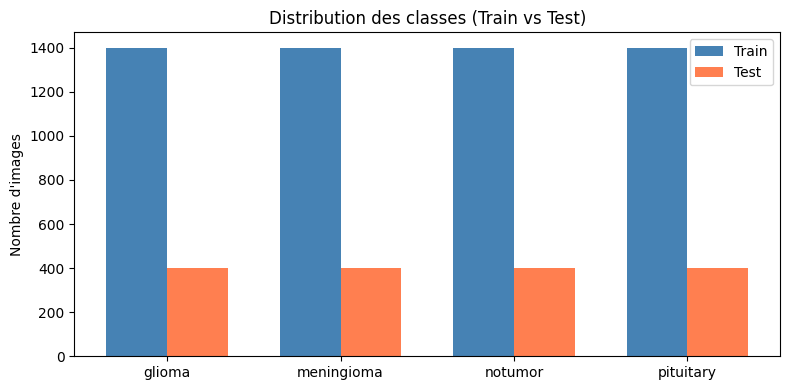

Train: {'glioma': 1400, 'meningioma': 1400, 'notumor': 1400, 'pituitary': 1400}
Test : {'glioma': 400, 'meningioma': 400, 'notumor': 400, 'pituitary': 400}
Total : 7200 images


In [37]:
train_counts = [len(os.listdir(os.path.join(TRAIN_DIR, c))) for c in CLASSES]
test_counts  = [len(os.listdir(os.path.join(TEST_DIR,  c))) for c in CLASSES]

x = np.arange(len(CLASSES))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - width/2, train_counts, width, label="Train", color="steelblue")
ax.bar(x + width/2, test_counts,  width, label="Test",  color="coral")
ax.set_xticks(x); ax.set_xticklabels(CLASSES)
ax.set_ylabel("Nombre d'images")
ax.set_title("Distribution des classes (Train vs Test)")
ax.legend(); plt.tight_layout(); plt.show()

print("Train:", dict(zip(CLASSES, train_counts)))
print("Test :", dict(zip(CLASSES, test_counts)))
print(f"Total : {sum(train_counts)+sum(test_counts)} images")

## Section 3 — Prétraitement

Pour chaque image :
1. Lecture depuis le sous-dossier de sa classe
2. Conversion en **niveaux de gris**
3. Redimensionnement à **128×128 pixels**
4. **Normalisation** des valeurs de pixels dans [0, 1] (division par 255)
5. Stockage dans des tableaux NumPy

In [38]:
def load_images(root_dir):
    images, labels = [], []
    for cls in CLASSES:
        folder = os.path.join(root_dir, cls)
        label  = CLASS_IDX[cls]
        files  = [f for f in os.listdir(folder)
                  if f.lower().endswith((".jpg", ".jpeg", ".png"))]
        for fname in tqdm(files, desc=f"  {cls}", leave=False):
            path = os.path.join(folder, fname)
            img  = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            img = img / 255.0          # normalize to [0, 1]
            images.append(img)
            labels.append(label)
    return np.array(images, dtype=np.float32), np.array(labels, dtype=np.int32)


print("Chargement et prétraitement — Train...")
X_train_img, y_train = load_images(TRAIN_DIR)
print("Chargement et prétraitement — Test...")
X_test_img,  y_test  = load_images(TEST_DIR)

print(f"\nX_train_img : {X_train_img.shape}  (float32, valeurs ∈ [0,1])")
print(f"X_test_img  : {X_test_img.shape}")
print(f"y_train     : {y_train.shape}  — classes : {np.unique(y_train)}")
print(f"y_test      : {y_test.shape}")

Chargement et prétraitement — Train...


Chargement et prétraitement — Test...



X_train_img : (5600, 128, 128)  (float32, valeurs ∈ [0,1])
X_test_img  : (1600, 128, 128)
y_train     : (5600,)  — classes : [0 1 2 3]
y_test      : (1600,)


## Section 4 — Augmentation des données (démonstration)

### Le dataset est-il déséquilibré ?

Non — chaque classe contient exactement **1 400 images d'entraînement et 400 de test**. Le dataset est **parfaitement équilibré**, donc une augmentation lourde n'est **pas nécessaire** pour corriger un biais de classe.

### Pourquoi quand même montrer l'augmentation ?

Même équilibré, le dataset peut bénéficier d'augmentation pour améliorer la **robustesse** du modèle (invariance à la rotation, au contraste, au flip). Mais comme les features manuelles utilisées ici (histogramme, texture, Laplacian) sont **déjà partiellement invariantes** (l'histogramme ne dépend pas de l'orientation des pixels), on choisit de **ne pas appliquer d'augmentation** à l'entraînement.

> **Décision :** pas d'augmentation appliquée pour ce projet — les exemples ci-dessous sont purement illustratifs.

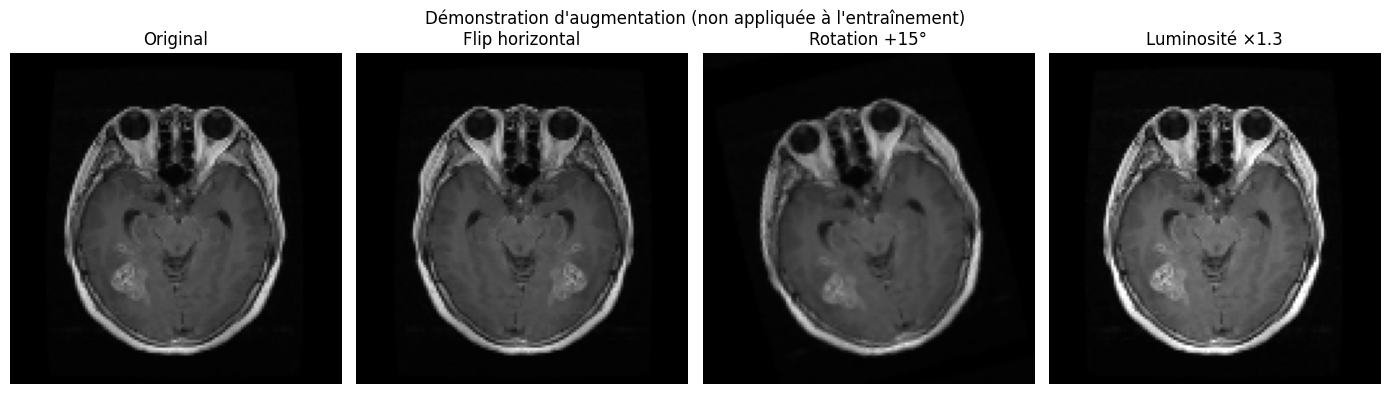

In [39]:
def augment_flip(img):
    return cv2.flip(img, 1)

def augment_rotate(img, angle=15):
    h, w = img.shape
    M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)
    return cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REFLECT)

def augment_brightness(img, factor=1.3):
    return np.clip(img * factor, 0, 1)


# Prendre une image gliome au hasard
idx = np.where(y_train == CLASS_IDX["glioma"])[0][0]
original = X_train_img[idx]

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
axes[0].imshow(original,                          cmap="gray", vmin=0, vmax=1); axes[0].set_title("Original")
axes[1].imshow(augment_flip(original),            cmap="gray", vmin=0, vmax=1); axes[1].set_title("Flip horizontal")
axes[2].imshow(augment_rotate(original, 15),      cmap="gray", vmin=0, vmax=1); axes[2].set_title("Rotation +15°")
axes[3].imshow(augment_brightness(original, 1.3), cmap="gray", vmin=0, vmax=1); axes[3].set_title("Luminosité ×1.3")
for ax in axes: ax.axis("off")
plt.suptitle("Démonstration d'augmentation (non appliquée à l'entraînement)", fontsize=12)
plt.tight_layout(); plt.show()

## Section 5 — Extraction de caractéristiques

Chaque image est représentée par un **vecteur de 517 features** :

| Groupe | Description | Taille |
|---|---|---|
| **Histogramme** | Distribution des niveaux de gris (256 bins) | 256 |
| **Texture** | Variance, énergie, entropie, contraste, homogénéité | 5 |
| **Contours (Laplacian)** | Histogramme de la carte de gradients Laplacian | 256 |

> Le **Laplacian** détecte les bords en calculant la dérivée seconde de l'intensité — plus sensible aux détails fins que Canny.

In [40]:
# ── Histogramme ──────────────────────────────────────────────────────────────
def histo(img):
    """Histogramme 256 bins sur l'image normalisée remappée en [0,255]."""
    img_u8 = (img * 255).astype(np.uint8)
    h, _   = np.histogram(img_u8.ravel(), bins=256, range=(0, 256))
    return h.astype(np.float64)


# ── Texture ───────────────────────────────────────────────────────────────────
def variance2(img):
    return np.var(img)

def energie(img):
    return np.sum(img ** 2) / img.size

def entropie(img):
    h, _ = np.histogram((img * 255).astype(np.uint8).ravel(),
                         bins=256, range=(0, 256))
    p = h / (h.sum() + 1e-10)
    return -np.sum(p * np.log2(p + 1e-10))

def contraste(img):
    return float(np.mean(np.abs(img[:, 1:] - img[:, :-1])))

def homogenite(img):
    return 1.0 / (1.0 + np.std(img))

def extract_texture(img):
    return np.array([variance2(img), energie(img), entropie(img),
                     contraste(img), homogenite(img)])


# ── Contours Laplacian ────────────────────────────────────────────────────────
def extract_edges(img):
    """Applique le filtre Laplacian et retourne l'histogramme de la carte de bords."""
    img_u8  = (img * 255).astype(np.uint8)
    lap     = cv2.Laplacian(img_u8, cv2.CV_64F)
    lap_u8  = np.clip(np.abs(lap), 0, 255).astype(np.uint8)
    h, _    = np.histogram(lap_u8.ravel(), bins=256, range=(0, 256))
    return h.astype(np.float64)


# ── Vecteur complet ───────────────────────────────────────────────────────────
def extract_features(img):
    """Concatène histogramme (256) + texture (5) + edges Laplacian (256) = 517."""
    return np.concatenate([histo(img), extract_texture(img), extract_edges(img)])


# ── Extraction sur tout le dataset ───────────────────────────────────────────
print("Extraction des features — Train...")
X_train = np.array([extract_features(img) for img in tqdm(X_train_img)])

print("Extraction des features — Test...")
X_test  = np.array([extract_features(img) for img in tqdm(X_test_img)])

print(f"\nTaille du vecteur de features : {X_train.shape[1]}")
print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")

Extraction des features — Train...


100%|██████████| 5600/5600 [00:05<00:00, 989.68it/s] 


Extraction des features — Test...


100%|██████████| 1600/1600 [00:01<00:00, 1067.10it/s]


Taille du vecteur de features : 517
X_train : (5600, 517)
X_test  : (1600, 517)


## Section 6 — Normalisation des features (StandardScaler)

**Pourquoi c'est essentiel pour KNN :**
KNN calcule des **distances euclidiennes**. Sans normalisation, les 256 bins de l'histogramme (valeurs jusqu'à ~16 000) **dominent totalement** les features de texture (valeurs < 1), faussant les distances.

`StandardScaler` centre chaque feature à **moyenne = 0** et **écart-type = 1**, donnant un poids égal à chaque dimension.

In [41]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Avant normalisation  — min: {X_train.min():.2f},  max: {X_train.max():.2f}")
print(f"Après normalisation  — min: {X_train_scaled.min():.2f},  max: {X_train_scaled.max():.2f}")
print(f"Moyenne par feature  ≈ {X_train_scaled.mean():.4f}")
print(f"Écart-type           ≈ {X_train_scaled.std():.4f}")

Avant normalisation  — min: 0.00,  max: 11264.00
Après normalisation  — min: -3.90,  max: 65.29
Moyenne par feature  ≈ 0.0000
Écart-type           ≈ 1.0000


## Section 7 — Optimisation du paramètre K

On teste plusieurs valeurs de K (nombre de voisins) et on choisit celle qui maximise l'accuracy sur le test set.

Tuning K: 100%|██████████| 8/8 [00:00<00:00, 13.28it/s]


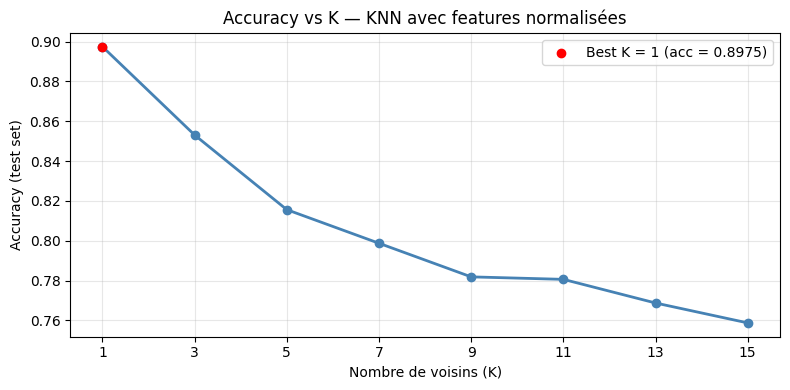


Meilleur K : 1  →  accuracy = 0.8975


In [42]:
k_values = [1, 3, 5, 7, 9, 11, 13, 15]
accuracies = []

for k in tqdm(k_values, desc="Tuning K"):
    model = KNeighborsClassifier(n_neighbors=k, metric="euclidean", n_jobs=-1)
    model.fit(X_train_scaled, y_train)
    acc = accuracy_score(y_test, model.predict(X_test_scaled))
    accuracies.append(acc)

best_k   = k_values[int(np.argmax(accuracies))]
best_acc = max(accuracies)

plt.figure(figsize=(8, 4))
plt.plot(k_values, accuracies, marker="o", linewidth=2, color="steelblue")
plt.scatter([best_k], [best_acc], color="red", zorder=5,
            label=f"Best K = {best_k} (acc = {best_acc:.4f})")
plt.xlabel("Nombre de voisins (K)")
plt.ylabel("Accuracy (test set)")
plt.title("Accuracy vs K — KNN avec features normalisées")
plt.xticks(k_values); plt.grid(alpha=0.3); plt.legend()
plt.tight_layout(); plt.show()

print(f"\nMeilleur K : {best_k}  →  accuracy = {best_acc:.4f}")

## Section 8 — Classification KNN (modèle final)

Entraînement du KNN final avec le **meilleur K** trouvé à l'étape précédente, sur les **features normalisées**.

In [43]:
knn = KNeighborsClassifier(n_neighbors=best_k, metric="euclidean", n_jobs=-1)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

print(f"Modèle KNN (K={best_k}) entraîné et prédictions effectuées.")

Modèle KNN (K=1) entraîné et prédictions effectuées.


## Section 9 — Évaluation du modèle KNN

Métriques calculées sur le jeu de test (1 600 images) :
- **Accuracy** : taux global de bonnes classifications
- **Precision** : parmi les images prédites classe X, combien sont correctes
- **Recall** : parmi les vraies images classe X, combien sont détectées
- **F1-score** : moyenne harmonique de precision et recall

In [44]:
acc_knn  = accuracy_score(y_test,  y_pred_knn)
prec_knn = precision_score(y_test, y_pred_knn, average="macro", zero_division=0)
rec_knn  = recall_score(y_test,    y_pred_knn, average="macro", zero_division=0)
f1_knn   = f1_score(y_test,        y_pred_knn, average="macro", zero_division=0)

print("=" * 50)
print(f"  KNN (K={best_k})")
print("=" * 50)
print(f"  Accuracy  : {acc_knn:.4f}  ({acc_knn*100:.2f} %)")
print(f"  Precision : {prec_knn:.4f}")
print(f"  Recall    : {rec_knn:.4f}")
print(f"  F1-score  : {f1_knn:.4f}")
print("=" * 50)
print()
print(classification_report(y_test, y_pred_knn, target_names=CLASSES, zero_division=0))

  KNN (K=1)
  Accuracy  : 0.8975  (89.75 %)
  Precision : 0.8999
  Recall    : 0.8975
  F1-score  : 0.8937

              precision    recall  f1-score   support

      glioma       0.92      0.70      0.80       400
  meningioma       0.83      0.91      0.87       400
     notumor       0.91      1.00      0.95       400
   pituitary       0.94      0.98      0.96       400

    accuracy                           0.90      1600
   macro avg       0.90      0.90      0.89      1600
weighted avg       0.90      0.90      0.89      1600



## Section 10 — Matrice de confusion KNN

Chaque ligne = classe réelle, chaque colonne = classe prédite.
La diagonale représente les **bonnes classifications**.

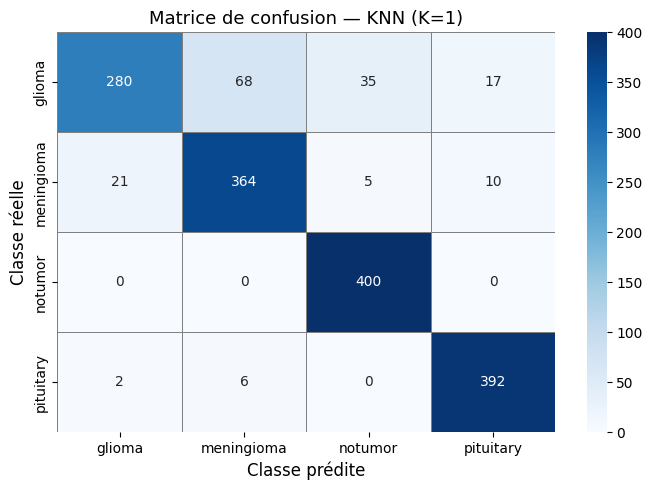

In [45]:
cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_knn, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASSES, yticklabels=CLASSES,
            linewidths=0.5, linecolor="gray")
plt.xlabel("Classe prédite", fontsize=12)
plt.ylabel("Classe réelle",  fontsize=12)
plt.title(f"Matrice de confusion — KNN (K={best_k})", fontsize=13)
plt.tight_layout(); plt.show()

## Section 11 — Visualisation des images mal classifiées

On extrait quelques exemples où le modèle s'est trompé pour comprendre **quelles classes sont les plus confondues** et **pourquoi** (similarité visuelle, contraste, position, etc.).

Total d'erreurs : 164 sur 1600 (10.2 %)

Top 5 des confusions (réel → prédit) :
  glioma       → meningioma   : 68 erreurs
  glioma       → notumor      : 35 erreurs
  meningioma   → glioma       : 21 erreurs
  glioma       → pituitary    : 17 erreurs
  meningioma   → pituitary    : 10 erreurs


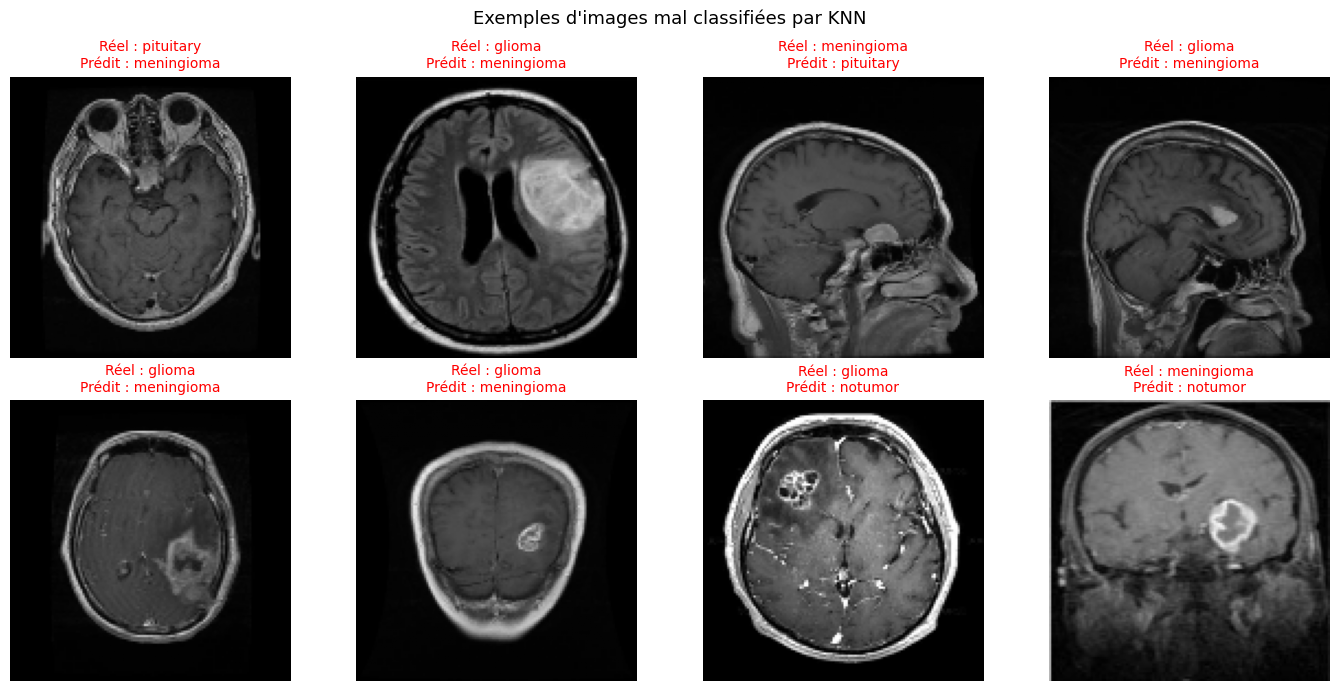

In [46]:
# Indices des erreurs
wrong_idx = np.where(y_test != y_pred_knn)[0]
print(f"Total d'erreurs : {len(wrong_idx)} sur {len(y_test)} ({len(wrong_idx)/len(y_test)*100:.1f} %)")

# Paires les plus confondues
pairs = [(CLASSES[y_test[i]], CLASSES[y_pred_knn[i]]) for i in wrong_idx]
pair_counts = pd.Series(pairs).value_counts().head(5)
print("\nTop 5 des confusions (réel → prédit) :")
for (real, pred), count in pair_counts.items():
    print(f"  {real:12s} → {pred:12s} : {count} erreurs")

# Échantillon de 8 erreurs (reproductible)
rng = np.random.default_rng(RANDOM_STATE)
sample = rng.choice(wrong_idx, size=min(8, len(wrong_idx)), replace=False)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, i in zip(axes.flat, sample):
    ax.imshow(X_test_img[i], cmap="gray", vmin=0, vmax=1)
    real = CLASSES[y_test[i]]
    pred = CLASSES[y_pred_knn[i]]
    ax.set_title(f"Réel : {real}\nPrédit : {pred}", color="red", fontsize=10)
    ax.axis("off")
plt.suptitle("Exemples d'images mal classifiées par KNN", fontsize=13)
plt.tight_layout(); plt.show()

## Section 12 — Comparaison avec Random Forest

On entraîne un **Random Forest** sur les **mêmes features normalisées** pour comparer ses performances à celles du KNN.
Random Forest est un **ensemble d'arbres de décision** — il est moins sensible à l'échelle des features et capture des **interactions non-linéaires** entre elles.

In [47]:
rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

acc_rf  = accuracy_score(y_test,  y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf, average="macro", zero_division=0)
rec_rf  = recall_score(y_test,    y_pred_rf, average="macro", zero_division=0)
f1_rf   = f1_score(y_test,        y_pred_rf, average="macro", zero_division=0)

print("=" * 50)
print(f"  Random Forest (n_estimators=200)")
print("=" * 50)
print(f"  Accuracy  : {acc_rf:.4f}  ({acc_rf*100:.2f} %)")
print(f"  Precision : {prec_rf:.4f}")
print(f"  Recall    : {rec_rf:.4f}")
print(f"  F1-score  : {f1_rf:.4f}")
print("=" * 50)
print()
print(classification_report(y_test, y_pred_rf, target_names=CLASSES, zero_division=0))

  Random Forest (n_estimators=200)
  Accuracy  : 0.8313  (83.12 %)
  Precision : 0.8284
  Recall    : 0.8313
  F1-score  : 0.8246

              precision    recall  f1-score   support

      glioma       0.80      0.59      0.68       400
  meningioma       0.77      0.81      0.79       400
     notumor       0.85      1.00      0.92       400
   pituitary       0.90      0.93      0.91       400

    accuracy                           0.83      1600
   macro avg       0.83      0.83      0.82      1600
weighted avg       0.83      0.83      0.82      1600



Comparaison KNN vs Random Forest :
           KNN (K=1)  Random Forest
Accuracy      0.8975         0.8312
Precision     0.8999         0.8284
Recall        0.8975         0.8312
F1-score      0.8937         0.8246



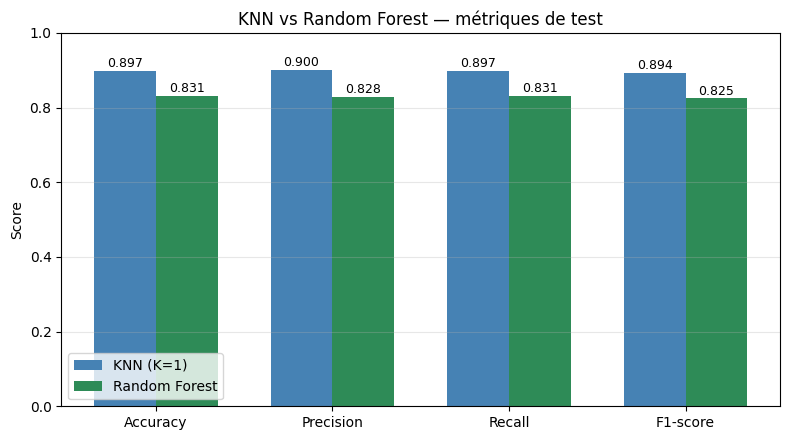

In [48]:
# Tableau de comparaison
comparison = pd.DataFrame({
    f"KNN (K={best_k})": [acc_knn, prec_knn, rec_knn, f1_knn],
    "Random Forest":     [acc_rf,  prec_rf,  rec_rf,  f1_rf],
}, index=["Accuracy", "Precision", "Recall", "F1-score"]).round(4)

print("Comparaison KNN vs Random Forest :")
print(comparison)
print()

# Bar chart comparatif
metrics = comparison.index.tolist()
knn_vals = comparison.iloc[:, 0].values
rf_vals  = comparison.iloc[:, 1].values

x = np.arange(len(metrics))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(x - width/2, knn_vals, width, label=f"KNN (K={best_k})", color="steelblue")
ax.bar(x + width/2, rf_vals,  width, label="Random Forest",      color="seagreen")
ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_ylabel("Score"); ax.set_ylim(0, 1)
ax.set_title("KNN vs Random Forest — métriques de test")
ax.legend(); ax.grid(axis="y", alpha=0.3)
for i, (k, r) in enumerate(zip(knn_vals, rf_vals)):
    ax.text(i - width/2, k + 0.01, f"{k:.3f}", ha="center", fontsize=9)
    ax.text(i + width/2, r + 0.01, f"{r:.3f}", ha="center", fontsize=9)
plt.tight_layout(); plt.show()

## Section 13 — Visualisation des exemples

Un exemple d'IRM par classe issu du jeu d'entraînement, affiché après prétraitement (niveaux de gris, 128×128, normalisé).

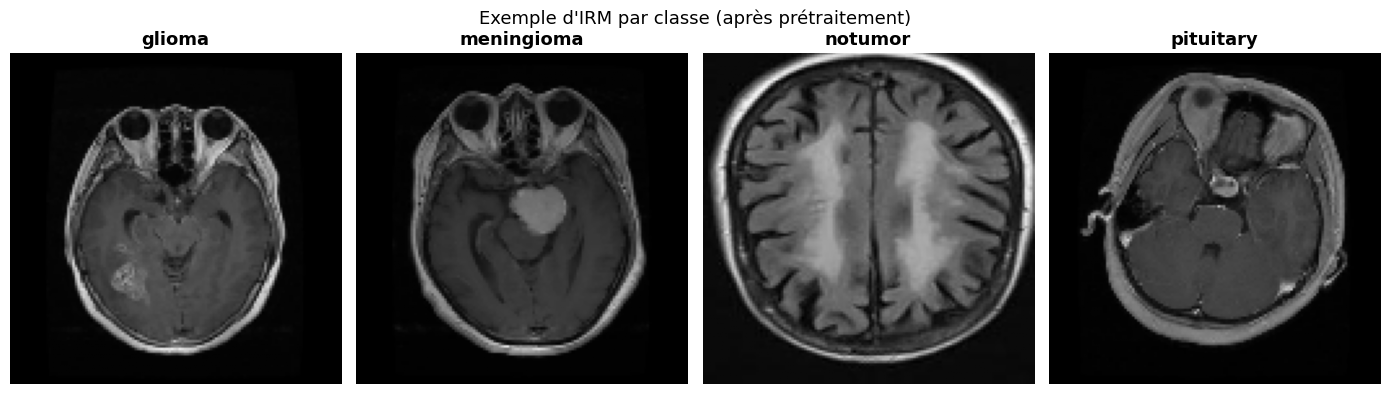

In [49]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4))

for ax, cls in zip(axes, CLASSES):
    # Prendre le premier index correspondant à cette classe
    idx = np.where(y_train == CLASS_IDX[cls])[0][0]
    img = X_train_img[idx]          # already grayscale, 128x128, [0,1]
    ax.imshow(img, cmap="gray", vmin=0, vmax=1)
    ax.set_title(cls, fontsize=13, fontweight="bold")
    ax.axis("off")

plt.suptitle("Exemple d'IRM par classe (après prétraitement)", fontsize=13)
plt.tight_layout()
plt.show()

## Section 14 — Sauvegarde des modèles pour le déploiement

Sauvegarde du `StandardScaler`, du KNN et du Random Forest dans `models/` pour les charger depuis l'application Flask.

In [50]:
import joblib

os.makedirs("models", exist_ok=True)

joblib.dump(scaler, "models/scaler.joblib")
joblib.dump(knn,    "models/knn.joblib")
joblib.dump(rf,     "models/rf.joblib")
joblib.dump({"classes": CLASSES, "img_size": IMG_SIZE, "best_k": int(best_k)},
            "models/meta.joblib")

print("Modèles sauvegardés dans ./models/")
for f in os.listdir("models"):
    size_kb = os.path.getsize(os.path.join("models", f)) / 1024
    print(f"  {f}  ({size_kb:.1f} KB)")

Modèles sauvegardés dans ./models/
  knn.joblib  (22663.3 KB)
  scaler.joblib  (12.7 KB)
  meta.joblib  (0.1 KB)
  rf.joblib  (20416.9 KB)
